[[11. 12.]
 [10.  8.]]


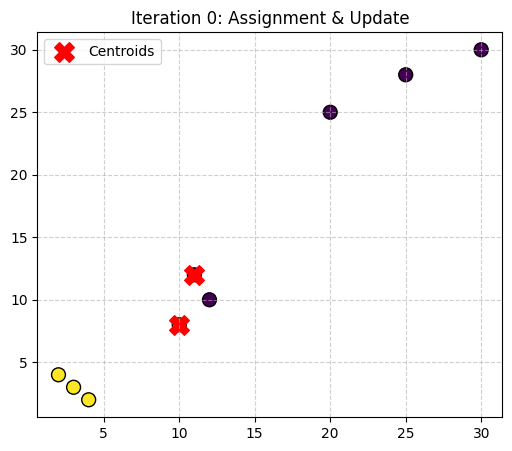

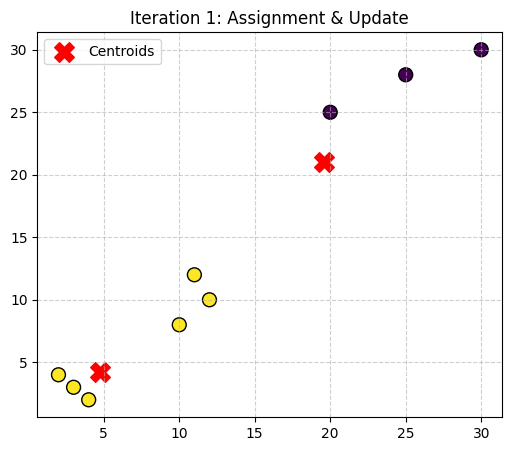

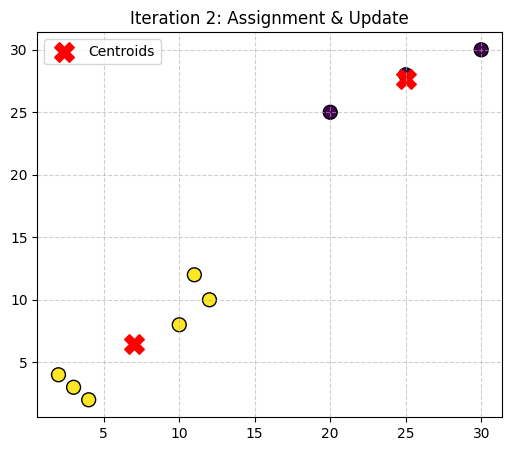

Converged at iteration 2


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#  Prepare Data
X = np.array([
    [2,4],[4,2],[10,8],[12,10],
    [3,3],[20,25],[30,30],[11,12],
    [25,28]
], dtype=float)
K = 2

#  Initialize Centroids 
np.random.seed(0)
initial_indices = np.random.choice(len(X), K, replace=False)
centroids = X[initial_indices].copy()

# K-Means Logic Loop
max_iters = 5
current_centroids = centroids.copy()

for i in range(max_iters):
    # Step A: Assignment (Find nearest centroid for each point)
    # Using Euclidean distance: sqrt((x1-x2)^2 + (y1-y2)^2)
    distances = np.linalg.norm(X[:, np.newaxis] - current_centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    
    # --- Visualization Code ---
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, edgecolors='k')
    plt.scatter(current_centroids[:, 0], current_centroids[:, 1], 
                c='red', marker='X', s=200, label='Centroids')
    plt.title(f"Iteration {i}: Assignment & Update")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Update (Calculate new means)
    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
    
    # Check for convergence (Stop if centroids don't move)
    if np.allclose(current_centroids, new_centroids):
        print(f"Converged at iteration {i}")
        break
    current_centroids = new_centroids